# Baseline Forecasting Models

The objective of this notebook is to establish classical forecasting baselines for the bike-sharing demand prediction task.

The following forecasting models are evaluated:
- Naive Forecast
- Seasonal Naive Forecast
- AutoARIMA

The models are evaluated using:
- MAE
- RMSE
- MASE

All models use the same chronological train-validation-test split to ensure fair comparison and reproducibility.

In [3]:
# imports
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from pmdarima import auto_arima

import warnings
warnings.filterwarnings("ignore")

In [4]:
# loading data
train = pd.read_csv(
    "../data/processed/train.csv",
    index_col=0,
    parse_dates=True
)

val = pd.read_csv(
    "../data/processed/val.csv",
    index_col=0,
    parse_dates=True
)

test = pd.read_csv(
    "../data/processed/test.csv",
    index_col=0,
    parse_dates=True
)

In [5]:
# data check
print(train.shape)
print(val.shape)
print(test.shape)

train.head()

(12165, 13)
(3475, 13)
(1739, 13)


,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,hum,windspeed,cnt
datetime,,,,,,,,,,,,,
2011-01-01 00:00:00,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.81,0.0,16
2011-01-01 01:00:00,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.80,0.0,40
2011-01-01 02:00:00,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.80,0.0,32
2011-01-01 03:00:00,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.75,0.0,13
2011-01-01 04:00:00,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.75,0.0,1


In [6]:
# defining metrics
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def mase(y_true, y_pred, train_series):
    
    naive_forecast = train_series[:-1]
    naive_actual = train_series[1:]
    
    mae_naive = mean_absolute_error(
        naive_actual,
        naive_forecast
    )
    
    mae_model = mean_absolute_error(
        y_true,
        y_pred
    )
    
    return mae_model / mae_naive


def evaluate_forecast(
    y_true,
    y_pred,
    train_series
):
    
    results = {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MASE": mase(y_true, y_pred, train_series)
    }
    
    return results

In [7]:
# test metrics
evaluate_forecast(
    val["cnt"],
    val["cnt"],
    train["cnt"]
)

{'MAE': 0.0, 'RMSE': np.float64(0.0), 'MASE': 0.0}

## Naive Forecast

The Naive Forecast predicts the next observation using the most recent observed value.

Formally:

\[
\hat{y}_t = y_{t-1}
\]

This model serves as a simple baseline for evaluating whether more advanced forecasting approaches provide meaningful improvements.

In [8]:
# validation forecast
naive_val_pred = val["cnt"].shift(1)

In [9]:
naive_val_pred.head()

datetime
2012-05-27 02:00:00     NaN
2012-05-27 03:00:00    61.0
2012-05-27 04:00:00    36.0
2012-05-27 05:00:00    11.0
2012-05-27 06:00:00     7.0
Name: cnt, dtype: float64

In [10]:
naive_val_pred = naive_val_pred.dropna()

val_actual = val["cnt"].iloc[1:]

In [11]:
# evaluation
naive_val_results = evaluate_forecast(
    val_actual,
    naive_val_pred,
    train["cnt"]
)

naive_val_results

{'MAE': 95.06102475532528,
 'RMSE': np.float64(139.74786696491478),
 'MASE': 1.7095901160064944}

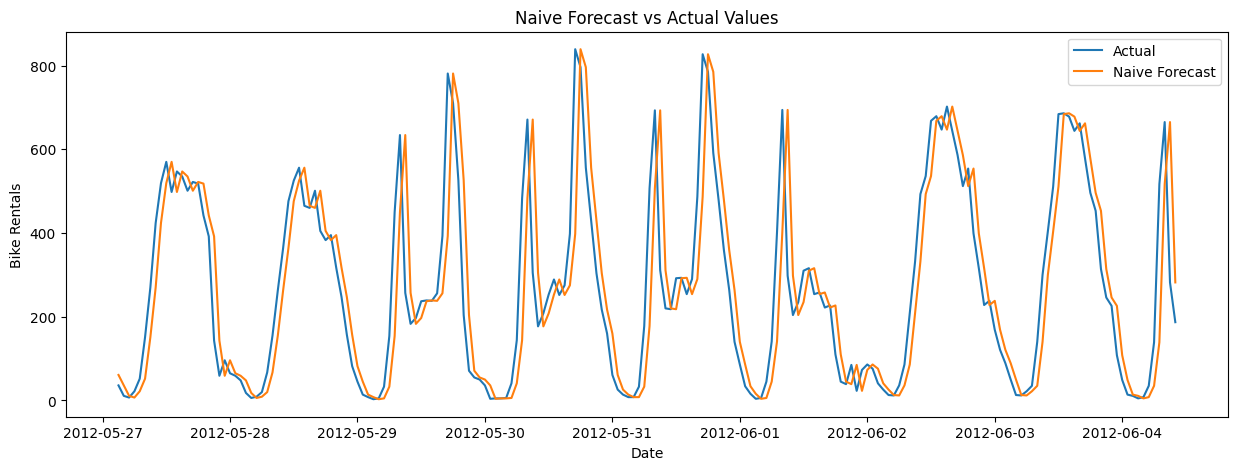

In [12]:
plt.figure(figsize=(15,5))

plt.plot(
    val_actual.index[:200],
    val_actual[:200],
    label="Actual"
)

plt.plot(
    naive_val_pred.index[:200],
    naive_val_pred[:200],
    label="Naive Forecast"
)

plt.title("Naive Forecast vs Actual Values")
plt.xlabel("Date")
plt.ylabel("Bike Rentals")

plt.legend()

plt.show()

The Naive Forecast captures short-term local continuity in the series but fails to model recurring daily seasonal patterns.

The relatively high forecasting errors suggest that relying only on the previous observation is insufficient for accurately predicting hourly bike rental demand.

This result indicates that explicit seasonality-aware forecasting approaches may provide substantial improvements.

In [13]:
# test forecast
naive_test_pred = test["cnt"].shift(1)

naive_test_pred = naive_test_pred.dropna()

test_actual = test["cnt"].iloc[1:]

In [14]:
# evaluation
naive_test_results = evaluate_forecast(
    test_actual,
    naive_test_pred,
    train["cnt"]
)

naive_test_results

{'MAE': 69.92635212888378,
 'RMSE': np.float64(109.63443807265799),
 'MASE': 1.25756481960534}

In [15]:
# validation vs test results comparison
naive_results_df = pd.DataFrame({
    "Validation": naive_val_results,
    "Test": naive_test_results
})

naive_results_df

,Validation,Test
MAE,95.061025,69.926352
RMSE,139.747867,109.634438
MASE,1.709590,1.257565


The Naive Forecast achieves relatively high forecasting errors on both the validation and test sets.

Although the model captures short-term continuity in the series, it fails to account for the strong daily seasonal structure identified during exploratory analysis.

This suggests that seasonality-aware forecasting approaches are likely to provide substantially better predictive performance.

## Seasonal Naive Forecast

The Seasonal Naive Forecast predicts future observations using the value observed during the same seasonal period in the past.

Given the strong daily seasonality identified during exploratory analysis, a seasonal period of 24 hours is used:

\[
\hat{y}_t = y_{t-24}
\]

This approach allows the model to capture recurring daily demand cycles.

In [16]:
# validation forecast 
seasonal_naive_val_pred = val["cnt"].shift(24)

In [17]:
seasonal_naive_val_pred = (
    seasonal_naive_val_pred.dropna()
)

seasonal_val_actual = val["cnt"].iloc[24:]

In [18]:
# evaluation
seasonal_naive_val_results = evaluate_forecast(
    seasonal_val_actual,
    seasonal_naive_val_pred,
    train["cnt"]
)

seasonal_naive_val_results

{'MAE': 84.93103448275862,
 'RMSE': np.float64(140.8822503416082),
 'MASE': 1.5274110232626859}

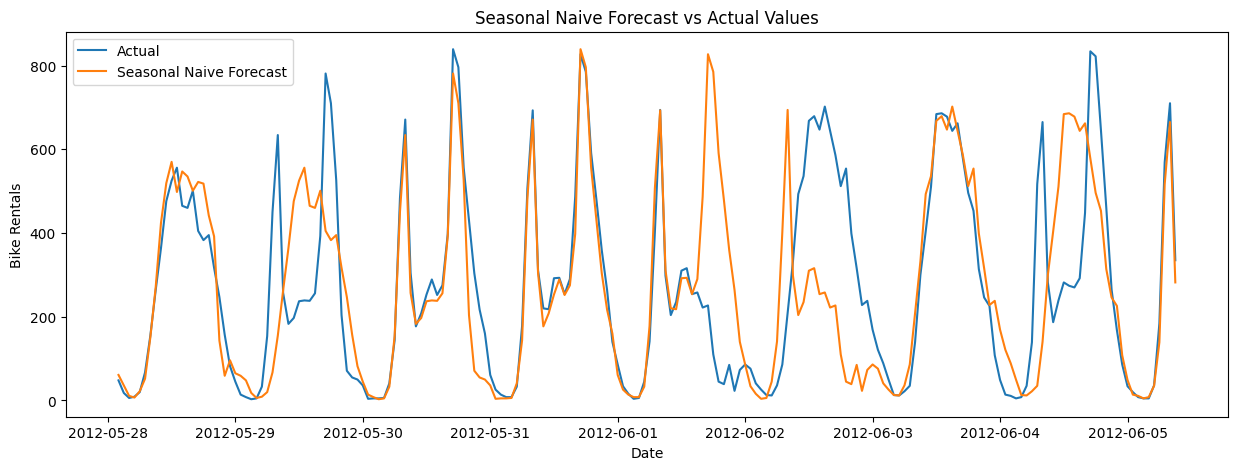

In [19]:
plt.figure(figsize=(15,5))

plt.plot(
    seasonal_val_actual.index[:200],
    seasonal_val_actual[:200],
    label="Actual"
)

plt.plot(
    seasonal_naive_val_pred.index[:200],
    seasonal_naive_val_pred[:200],
    label="Seasonal Naive Forecast"
)

plt.title("Seasonal Naive Forecast vs Actual Values")

plt.xlabel("Date")
plt.ylabel("Bike Rentals")

plt.legend()

plt.show()

The Seasonal Naive Forecast captures recurring daily demand cycles more effectively than the standard Naive Forecast.

Using observations from the same hour of the previous day improves short-term forecasting performance, particularly for regular commuting-related demand patterns.

However, the model still struggles to capture abrupt demand fluctuations and larger peaks, which contributes to relatively high RMSE values.

In [20]:
# test forecast
seasonal_naive_test_pred = (
    test["cnt"].shift(24)
)

seasonal_naive_test_pred = (
    seasonal_naive_test_pred.dropna()
)

seasonal_test_actual = (
    test["cnt"].iloc[24:]
)

In [21]:
# test evaluation
seasonal_naive_test_results = evaluate_forecast(
    seasonal_test_actual,
    seasonal_naive_test_pred,
    train["cnt"]
)

seasonal_naive_test_results

{'MAE': 74.22915451895044,
 'RMSE': np.float64(123.50846101255962),
 'MASE': 1.3349469902280588}

In [22]:
seasonal_results_df = pd.DataFrame({
    "Validation": seasonal_naive_val_results,
    "Test": seasonal_naive_test_results
})

seasonal_results_df

,Validation,Test
MAE,84.931034,74.229155
RMSE,140.882250,123.508461
MASE,1.527411,1.334947


In [23]:
comparison_df = pd.DataFrame({
    "Naive Validation": naive_val_results,
    "Naive Test": naive_test_results,
    "Seasonal Validation": seasonal_naive_val_results,
    "Seasonal Test": seasonal_naive_test_results
})

comparison_df

,Naive Validation,Naive Test,Seasonal Validation,Seasonal Test
MAE,95.061025,69.926352,84.931034,74.229155
RMSE,139.747867,109.634438,140.882250,123.508461
MASE,1.709590,1.257565,1.527411,1.334947


The forecasting results indicate that incorporating daily seasonality improves validation performance compared to the standard Naive Forecast.

However, the Seasonal Naive model does not generalize as effectively on the test set, where the standard Naive Forecast achieves lower forecasting errors.

These results suggest that although strong daily seasonality exists in the dataset, additional temporal dynamics and external factors influence bike rental demand beyond simple repeating daily patterns.

## AutoARIMA Forecast

AutoARIMA automatically selects the optimal ARIMA model configuration based on statistical criteria.

The model attempts to capture:
- autoregressive dependencies,
- trend,
- differencing structure,
- and moving-average components.

The model is trained exclusively on the training subset using only the target variable (`cnt`).

Based on the exploratory analysis, daily seasonality is incorporated using a seasonal period of 24 hours, reflecting the strong recurring hourly demand cycles observed in the dataset.

This model serves as a classical statistical forecasting baseline for comparison with more advanced forecasting approaches.

In [24]:
from pmdarima import auto_arima

#### training the model
auto_arima_model = auto_arima(
    train["cnt"],

    seasonal=True,
    m=24,

    stepwise=True,
    trace=True,

    suppress_warnings=True,
    error_action="ignore",

    max_p=2,
    max_q=2,

    max_P=1,
    max_Q=1,

    max_d=1,
    max_D=1,

    n_jobs=1
)

To improve computational efficiency and avoid excessive memory consumption, the AutoARIMA parameter search space was constrained to a limited range of autoregressive and moving-average orders.

This approach preserves the automatic model selection procedure while ensuring practical training time and reproducibility.

#### train_subset = train["cnt"].iloc[-3000:]

#### auto_arima_model = auto_arima(
    train_subset,

    seasonal=True,
    m=24,

    stepwise=True,
    trace=True,

    suppress_warnings=True,
    error_action="ignore",

    max_p=2,
    max_q=2,

    max_P=1,
    max_Q=1,

    max_d=1,
    max_D=1,

    n_jobs=1
)

Due to the computational complexity of seasonal AutoARIMA models on long hourly time series, the automatic parameter selection procedure was performed using the most recent subset of the training data.

This approach preserves the automatic model selection process while substantially reducing memory consumption and training time.

Since neither the limited range of parameters and limited test subsample weren't helpfull due to huge computational complexity, we decided to chech the AutoARIMA withot seasonal specification

#### AutoARIMA Forecast

The AutoARIMA model is used as a classical statistical forecasting baseline.

To ensure computational feasibility on the long hourly time series, a non-seasonal AutoARIMA specification is applied. The model automatically selects the optimal autoregressive, differencing, and moving-average orders based on statistical information criteria.

Daily seasonality effects are evaluated separately through the Seasonal Naive Forecast baseline.

In [25]:
auto_arima_model = auto_arima(
    train["cnt"],

    seasonal=False,

    stepwise=True,
    trace=True,

    suppress_warnings=True,
    error_action="ignore",

    max_p=3,
    max_q=3,
    max_d=2,

    n_jobs=1
)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=140659.610, Time=7.00 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=142873.945, Time=0.49 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=141821.603, Time=1.06 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=141145.208, Time=3.72 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=142871.945, Time=0.27 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=16.59 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=140659.408, Time=3.20 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=141103.262, Time=6.78 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=140663.744, Time=1.51 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=140660.475, Time=2.68 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=140659.230, Time=1.97 sec
 ARIMA(3,1,0)(0,0,0)[0]             : AIC=140657.230, Time=1.09 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=140661.744, Time=0.80 sec
 ARIMA(3,1,1)(0,0,0)[0]             : AIC=140658.475, Time=1.31 sec
 ARIMA(2,1,

The AutoARIMA procedure selected an ARIMA(3,1,0) model based on the lowest Akaike Information Criterion (AIC).

This indicates that the bike rental time series exhibits strong short-term autoregressive behavior, while differencing was required to improve stationarity.

The selected model does not include a moving-average component, suggesting that autoregressive dependencies alone provided the best statistical fit among the tested configurations.

In [26]:
# validation forecast
auto_arima_val_pred = auto_arima_model.predict(
    n_periods=len(val)
)

In [27]:
#evaluation
auto_arima_val_results = evaluate_forecast(
    val["cnt"],
    auto_arima_val_pred,
    train["cnt"]
)

auto_arima_val_results

{'MAE': 232.18217966452502,
 'RMSE': np.float64(308.4989441501566),
 'MASE': 4.175595208330424}

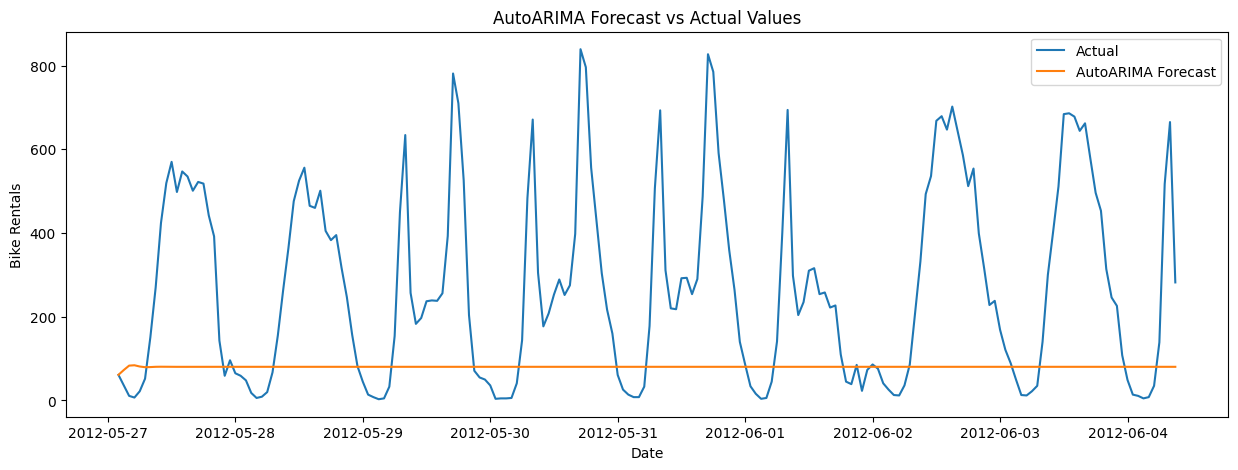

In [28]:
plt.figure(figsize=(15,5))

plt.plot(
    val.index[:200],
    val["cnt"][:200],
    label="Actual"
)

plt.plot(
    val.index[:200],
    auto_arima_val_pred[:200],
    label="AutoARIMA Forecast"
)

plt.title("AutoARIMA Forecast vs Actual Values")

plt.xlabel("Date")
plt.ylabel("Bike Rentals")

plt.legend()

plt.show()

In [30]:
# test forecast
auto_arima_test_pred = auto_arima_model.predict(
    n_periods=len(test)
)

In [31]:
# test evaluation
auto_arima_test_results = evaluate_forecast(
    test["cnt"],
    auto_arima_test_pred,
    train["cnt"]
)

auto_arima_test_results

{'MAE': 159.01083175395024,
 'RMSE': np.float64(224.45465052081923),
 'MASE': 2.859671952876738}

The AutoARIMA model also produced substantially worse forecasting performance on the test set compared to the Naive and Seasonal Naive baselines.

Although the automatic model selection procedure identified statistically significant autoregressive structure in the training data, the resulting model failed to generalize effectively to unseen observations.

The large forecasting errors suggest that the hourly bike rental series contains complex temporal dependencies and strong recurring behavioral patterns that cannot be adequately modeled using a simple non-seasonal ARIMA process.

These findings motivate the use of more advanced forecasting approaches capable of capturing nonlinear dynamics and richer seasonal structure.

In [ ]:
from pmdarima import auto_arima

In [ ]:
# ============================================================
# AUTOARIMA BASELINE
# ============================================================

from pmdarima import auto_arima


# ------------------------------------------------------------
# TRAIN AUTOARIMA MODEL
# ------------------------------------------------------------

auto_arima_model = auto_arima(
    train["cnt"],

    # seasonal structure
    seasonal=True,
    m=24,

    # automatic search
    stepwise=True,
    trace=True,

    # robustness
    suppress_warnings=True,
    error_action="ignore",

    # search space
    max_p=3,
    max_q=3,
    max_d=2,

    max_P=2,
    max_Q=2,
    max_D=1,

    # optimization
    n_jobs=1
)


# ------------------------------------------------------------
# MODEL SUMMARY
# ------------------------------------------------------------

print(auto_arima_model.summary())

In [ ]:
# ============================================================
# VALIDATION FORECAST
# ============================================================

auto_arima_val_pred = auto_arima_model.predict(
    n_periods=len(val)
)

auto_arima_val_results = evaluate_forecast(
    val["cnt"],
    auto_arima_val_pred,
    train["cnt"]
)

auto_arima_val_results

In [ ]:
# ============================================================
# TEST FORECAST
# ============================================================

auto_arima_test_pred = auto_arima_model.predict(
    n_periods=len(test)
)

auto_arima_test_results = evaluate_forecast(
    test["cnt"],
    auto_arima_test_pred,
    train["cnt"]
)

auto_arima_test_results

In [ ]:
# ============================================================
# VISUALIZATION
# ============================================================

plt.figure(figsize=(15,5))

plt.plot(
    test.index[:200],
    test["cnt"][:200],
    label="Actual"
)

plt.plot(
    test.index[:200],
    auto_arima_test_pred[:200],
    label="AutoARIMA Forecast"
)

plt.title("AutoARIMA Forecast vs Actual Values")

plt.xlabel("Date")
plt.ylabel("Bike Rentals")

plt.legend()

plt.show()